# Simulating Diagnostic Tests: How Reliable is a Positive Result?

In this notebook, you'll simulate test results for three diseases using a realistic population and test characteristics.

Each test has:
- **Sensitivity (True Positive Rate):** 99%
- **Specificity (True Negative Rate):** 99%

You’ll explore how different disease **prevalence rates** change the probability that someone who tested positive actually has the disease.


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Ensure reproducibility
np.random.seed(20250922)

# Test characteristics
SENSITIVITY = 0.99
SPECIFICITY = 0.99

# Population size
N = 100_000


## Simulating a One Population Instance

In the next cell, write a function that task as input disease prevalence (i.e., the fraction of the population that has the disease) and the population size and returns the following values: 
  * `prevalence`: It's handy to have this returned, even though it's being passed in.
  * `true_positives`: the number of population members who have the disease *and* a positive test.
  * `false_positives`: the number of population members who don't have the disease, but received a positive test.
  * `total_positives`: the sum of the previous two values.
  * `posterior`: This is simply the ratio of `true_positives` to `total_positives`. The term "posterior" is the statistical term for the value we're seeking, $P(\text{Disease}|\text{Positive Test})$.

I recommend returning the values in a dictionary, and I've built a stub for you.

Note, you can use `np.random.random` to generate a single random value between 0 and 1. If you'd like to generate a larger number of values at once, `random.rand` will do the trick. For instance, `np.random.rand(10)` will give you 10 random numbers between 0 and 1.

In [20]:
def simulate_test(prevalence, sensitivity=SENSITIVITY, specificity=SPECIFICITY, n=N):
    # Step 1: Simulate who has the disease
    disease_status = np.random.rand(n) < prevalence
    

    # Step 2: Simulate test results
    test_results = np.zeros(n,dtype=bool)
    test_results[disease_status] = np.random.rand(disease_status.sum()) < sensitivity
    test_results[~disease_status] = np.random.rand((~disease_status).sum()) < (1 - specificity)
    
    # Step 3: Calculate posterior probability: P(Disease | Test Positive)
    true_positives = np.sum(disease_status & test_results) #people who have the disease and tested positive
    false_positives = np.sum(~disease_status & test_results) #people who don’t have the disease but tested positive
    total_positives = true_positives + false_positives
    posterior = true_positives / total_positives if total_positives > 0 else np.nan

    return {
        'prevalence': prevalence,
        'true_positives': true_positives,
        'false_positives': false_positives,
        'total_positives': total_positives,
        'posterior': posterior
    }


If you've written your above function correctly to simulate the values listed, the code below will display them in a nice table.  

In [21]:
# Define prevalences
prevalences = {
    "Disease A (5%)": 0.05,
    "Disease B (0.5%)": 0.005,
    "Disease C (0.05%)": 0.0005,
}

results = []

for name, p in prevalences.items():
    res = simulate_test(prevalence=p)
    res['disease'] = name
    results.append(res)

experiments = pd.DataFrame(results)
experiments = experiments[['disease', 'prevalence', 'true_positives', 'false_positives', 'total_positives', 'posterior']] # put the columns in order
experiments


,disease,prevalence,true_positives,false_positives,total_positives,posterior
0,Disease A (5%),0.0500,4873,989,5862,0.831286
1,Disease B (0.5%),0.0050,513,1018,1531,0.335075
2,Disease C (0.05%),0.0005,39,1068,1107,0.035230


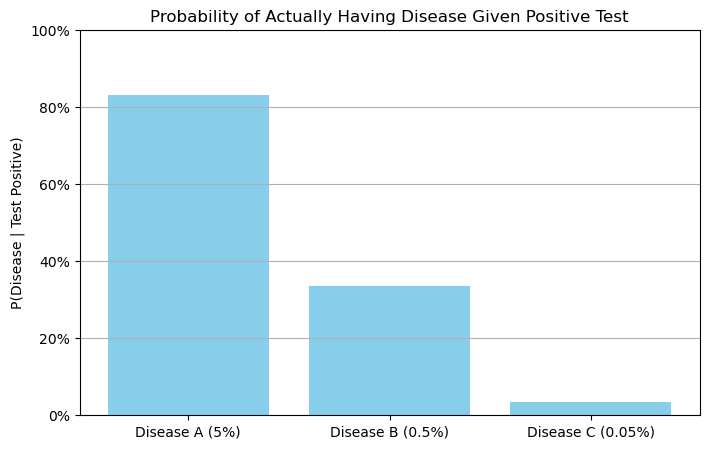

In [22]:
# And this code will make you a nice plot
plt.figure(figsize=(8,5))
plt.bar(experiments['disease'], experiments['posterior'], color='skyblue')
plt.ylabel('P(Disease | Test Positive)')
plt.title('Probability of Actually Having Disease Given Positive Test')
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))  # Format as percentages 
plt.grid(axis='y')
plt.show()


## Reflection One

Q: What do you notice about how the posterior probability changes with disease prevalence?

A: <!-- Your answer around here. Remember to remove the comment characters! --> The posterior probability P(Disease|Test Positive) increases as disease prevalence increases.

Q: Why is the probability of truly having the disease so low in some cases, even with a highly accurate test?

A: <!-- Your answer around here. Remember to remove the comment characters! --> Even with a highly accurate test (99% sensitivity and specificity), when a disease is very rare, there are many more healthy people than sick people in the population. The 1% false positive rate applied to a large healthy population generates more false positives than there are true positives from the small sick population.


--- 

### Repeating the Experiment

We've carried out two steps of our sequence to understand probability: we built a data generating process and calculated a statistic from it. Now let's take it a step further and repeat this process a thousand times to estimate the variability of that number. Note: this step is more about practicing our techniques than generating insights. The results of your reflections above are the traditional stopping point for a Bayes Theorem analysis of posteriors. 

In the code cell below, pick _one_ of the diseases from the first section. Simulate the posterior probability a large number of times. (Depending on the speed of your machine the number of simulations could be as small as 100 or large, like 10000. On mine, 10000 simulations took 10 seconds.) Plot those results and comment briefly on the range of outcomes in the reflection section.

In [23]:
# Your experiment code here
num_simulations = 1000


posterior_results = []

for _ in range(num_simulations):
    res = simulate_test(prevalence=0.0005)  # Disease C
    posterior_results.append(res['posterior'])


posterior_results = np.array(posterior_results)


print(f"Mean posterior: {posterior_results.mean():.4f}")
print(f"Min posterior: {posterior_results.min():.4f}")
print(f"Max posterior: {posterior_results.max():.4f}")
print(f"Standard deviation: {posterior_results.std():.4f}")

Mean posterior: 0.0469
Min posterior: 0.0286
Max posterior: 0.0679
Standard deviation: 0.0067


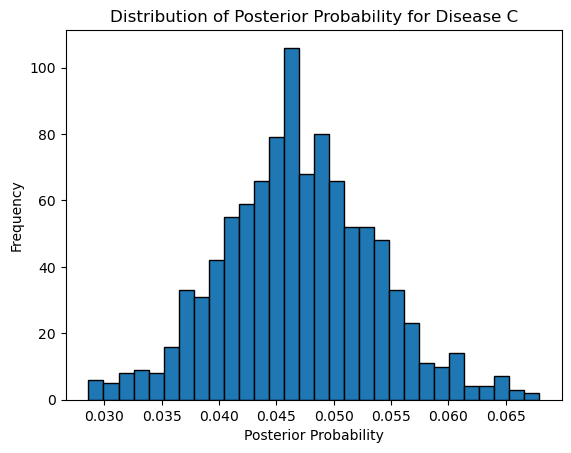

In [24]:
# Your plot code here. Feel free to use AI to make you a nice chart!
plt.hist(posterior_results, bins=30, edgecolor='black')
plt.xlabel('Posterior Probability')
plt.ylabel('Frequency')
plt.title('Distribution of Posterior Probability for Disease C')
plt.show()

## Reflection Two

Q: How much variability do you see around your mean value? 

A: <!-- Your answer around here. Remember to remove the comment characters! --> The variability is small. When we ran 1,000 simulations, the mean was 4.7%  with a standard deviation of 0.67%. The results ranged from 2.6% to 6.9%, with most values falling between 4% and 5%. The small standard deviation shows the results didn't jump around a lot. They clustered tightly around the mean.

Q: If we repeated the same simulation with one of the other diseases, how would you expect the distribution to shift? Why? 

A: <!-- Your answer around here. Remember to remove the comment characters! -->If we repeated the simulation for Disease A (5% prevalence) or Disease B (0.5% prevalence), the distribution of posterior probabilities would shift higher compared to Disease C. This is because these diseases are more common, so a larger fraction of positive test results are true positives rather than false positives. As a result, the chance that someone who tests positive actually has the disease increases with higher prevalence, meaning the posterior probability is higher and the distribution moves upward.

Q: Imagine you are the doctor in this situation with a patient who has just received a positive test. What would you communicate to them? 

A: <!-- Your answer around here. Remember to remove the comment characters! --> I would explain to the patient that even though they tested positive, the disease is extremely rare. So there’s still a low chance they actually have it. I’d recommend confirming the result with additional tests before making any decisions, and reassure them that a positive test does not automatically mean they are sick.
